In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
import os
print(os.getcwd())
print(os.listdir("."))

/home/akarimzadeh/Solar_ai_project/solar_ai_project/notebooks
['Untitled.ipynb', '.ipynb_checkpoints', 'Solar _power.ipynb', 'Solar.ipynb']


In [4]:
# ##
# sns.heatmap(
#     df.corr(numeric_only=True),
#     annot=True,
#     cmap="coolwarm"
# )##

### Correlation Analysis

Solar power output is strongly correlated with solar irradiance variables and sun elevation. Direct irradiance (0.94), reflected irradiance (0.97), and sun elevation (0.82) show the strongest relationships with power production, confirming that sunlight availability is the primary driver of photovoltaic performance.

Temperature exhibits a moderate positive correlation (0.37), while wind speed has almost no relationship with power output. Several irradiance variables are also highly correlated with one another, indicating potential multicollinearity within the dataset.

In [5]:
#X = df[
    [
        "direct_irradiance",
        "diffuse_irradiance",
        "reflected_irradiance",
        "sun_elevation",
        "temperature",
        "wind_speed",
        "Hour",
        "month"
    ]
]

y = df["power"]#

IndentationError: unexpected indent (530082047.py, line 2)

In [6]:
#from sklearn.model_selection import train_test_split

#train_size = int(len(df) * 0.8)

#X_train = X[:train_size]
#X_test = X[train_size:]

#y_train = y[:train_size]
#y_test = y[train_size:]

In [7]:
# print(X_train.shape)
# print(X_test.shape)
# print(y_train.shape)
# print(y_test.shape)

In [8]:
# from sklearn.ensemble import RandomForestRegressor

# model = RandomForestRegressor(
#     n_estimators=100,
#     random_state=42
# )

# model.fit(X_train, y_train)

In [9]:
# importance = pd.Series(
#     model.feature_importances_,
#     index=X.columns
# ).sort_values(ascending=False)

# print(importance)

In [10]:
#y_pred = model.predict(X_test)

In [11]:
# from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
# import numpy as np

# mae = mean_absolute_error(y_test, y_pred)
# rmse = np.sqrt(mean_squared_error(y_test, y_pred))
# r2 = r2_score(y_test, y_pred)

# print(f"MAE: {mae:.2f}")
# print(f"RMSE: {rmse:.2f}")
# print(f"R²: {r2:.4f}")

In [12]:
# plt.figure(figsize=(8,6))
# plt.scatter(y_test, y_pred, alpha=0.3)

# plt.xlabel("Actual Power")
# plt.ylabel("Predicted Power")
# plt.title("Actual vs Predicted Solar Power")

# plt.show()

In [13]:
# importance.plot(kind="bar")
# plt.title("Feature Importance")
# plt.ylabel("Importance")
# plt.show()

### *But — this model basically learned:

"more sun = more power"

...and not much else. It found irradiance so useful that it ignored temperature, even though temperature genuinely affects panel efficiency in reality.*

In [14]:
# import seaborn as sns

# # Check correlation
# print(df[['direct_irradiance', 'temperature']].corr())

# # Visualize
# sns.scatterplot(x="direct_irradiance", y='temperature', data=df)

# Photovoltaic Power Prediction Using Machine Learning

## 1. Project Overview

## 2. Data Collection

## 3. Data Cleaning & Preprocessing

## 4. Exploratory Data Analysis (EDA)

### 4.1 Dataset Overview

### 4.2 PV Power Distribution

### 4.3 Monthly Power Production

### 4.4 Correlation Analysis

## 5. Feature Engineering

## 6. Machine Learning Models

### 6.1 Linear Regression

### 6.2 Random Forest

## 7. Model Evaluation

## 8. Results & Discussion

## 9. Conclusion

## 1. Project Overview
### Predicting Photovoltaic Power Output Using Machine Learning
As someone with a background in physics and a strong interest in renewable energy, I have often wondered how much electricity solar panels on my roof could generate. This question inspired me to explore solar power prediction using data science and machine learning.

In this project, I use hourly PVGIS data from Aachen (https://re.jrc.ec.europa.eu/pvg_tools/en/tools.html)
, Germany (2015–2023) to investigate whether a machine learning model can learn the relationship between environmental conditions and photovoltaic (PV) power output. The dataset includes variables such as solar irradiance, temperature, wind speed, and solar elevation, which are used to train and evaluate a Random Forest model.

Beyond prediction accuracy, I am interested in understanding how environmental factors influence solar energy generation and how effectively machine learning can model these relationships.

The ultimate goal is to develop a simple web application that estimates the power output of a rooftop solar system in Aachen based on weather and solar radiation conditions. This project sits at the intersection of physics and data science — fields I know well — and turns that knowledge into something a homeowner can actually use.


## 2. Data Loading

In [15]:
df = pd.read_csv(
    "../data/Timeseries_Aachen_2015_2023.csv",skiprows=10
)

df.head()

/tmp/ipykernel_3777/1649801985.py:1: DtypeWarning: Columns (1) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(


,time,P,Gb(i),Gd(i),Gr(i),H_sun,T2m,WS10m,Int
0,20150101:0010,0.0,0.0,0.0,0.0,0.0,-0.53,2.48,0.0
1,20150101:0110,0.0,0.0,0.0,0.0,0.0,-0.81,2.55,0.0
2,20150101:0210,0.0,0.0,0.0,0.0,0.0,-0.88,2.48,0.0
3,20150101:0310,0.0,0.0,0.0,0.0,0.0,-1.19,2.62,0.0
4,20150101:0410,0.0,0.0,0.0,0.0,0.0,-1.48,2.97,0.0


In [16]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 78897 entries, 0 to 78896
Data columns (total 9 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   time    78897 non-null  object 
 1   P       78889 non-null  object 
 2   Gb(i)   78888 non-null  float64
 3   Gd(i)   78888 non-null  float64
 4   Gr(i)   78888 non-null  float64
 5   H_sun   78888 non-null  float64
 6   T2m     78888 non-null  float64
 7   WS10m   78888 non-null  float64
 8   Int     78888 non-null  float64
dtypes: float64(7), object(2)
memory usage: 5.4+ MB


In [17]:
df.describe()

,Gb(i),Gd(i),Gr(i),H_sun,T2m,WS10m,Int
count,78888.000000,78888.000000,78888.000000,78888.000000,78888.000000,78888.000000,78888.0
mean,85.170418,66.581921,2.351533,12.928812,10.265943,3.441691,0.0
std,186.940963,95.326680,3.797957,17.556915,7.095264,1.797210,0.0
min,0.000000,0.000000,0.000000,0.000000,-11.810000,0.000000,0.0
25%,0.000000,0.000000,0.000000,0.000000,4.890000,2.140000,0.0
50%,0.000000,0.000000,0.000000,0.000000,9.960000,3.100000,0.0
75%,40.952500,119.910000,3.330000,22.530000,15.450000,4.480000,0.0
max,962.610000,426.770000,17.090000,62.200000,37.120000,12.970000,0.0


## 3. Data Cleaning & Preprocessing


In [18]:
df = df.dropna()
df.isna().sum()


time     0
P        0
Gb(i)    0
Gd(i)    0
Gr(i)    0
H_sun    0
T2m      0
WS10m    0
Int      0
dtype: int64

In [19]:
df["Int"].unique()

array([0.])

In [20]:
df = df.drop(columns=["Int"])
df.columns

Index(['time', 'P', 'Gb(i)', 'Gd(i)', 'Gr(i)', 'H_sun', 'T2m', 'WS10m'], dtype='object')

In [21]:
df = df.rename(columns={
    "P": "power",
    "Gb(i)": "direct_irradiance",
    "Gd(i)": "diffuse_irradiance",
    "Gr(i)": "reflected_irradiance",
    "H_sun": "sun_elevation",
    "T2m": "temperature",
    "WS10m": "wind_speed",
    "Int": "irradiance_index"
})
df.head()

,time,power,direct_irradiance,diffuse_irradiance,reflected_irradiance,sun_elevation,temperature,wind_speed
0,20150101:0010,0.0,0.0,0.0,0.0,0.0,-0.53,2.48
1,20150101:0110,0.0,0.0,0.0,0.0,0.0,-0.81,2.55
2,20150101:0210,0.0,0.0,0.0,0.0,0.0,-0.88,2.48
3,20150101:0310,0.0,0.0,0.0,0.0,0.0,-1.19,2.62
4,20150101:0410,0.0,0.0,0.0,0.0,0.0,-1.48,2.97


In [22]:
df["time"].dtype

dtype('O')

In [23]:
df["time"] = pd.to_datetime(
    df["time"],
    format="%Y%m%d:%H%M"
)

In [24]:
df["Hour"] = df["time"].dt.hour
df["month"] = df["time"].dt.month
df["day_of_year"] = df["time"].dt.dayofyear
df.head()

,time,power,direct_irradiance,diffuse_irradiance,reflected_irradiance,sun_elevation,temperature,wind_speed,Hour,month,day_of_year
0,2015-01-01 00:10:00,0.0,0.0,0.0,0.0,0.0,-0.53,2.48,0,1,1
1,2015-01-01 01:10:00,0.0,0.0,0.0,0.0,0.0,-0.81,2.55,1,1,1
2,2015-01-01 02:10:00,0.0,0.0,0.0,0.0,0.0,-0.88,2.48,2,1,1
3,2015-01-01 03:10:00,0.0,0.0,0.0,0.0,0.0,-1.19,2.62,3,1,1
4,2015-01-01 04:10:00,0.0,0.0,0.0,0.0,0.0,-1.48,2.97,4,1,1


In [25]:
df["power"].sample(10)

62214       0.0
6683     189.67
32869    225.24
52208       0.0
51119       0.0
22131       0.0
48370     95.44
34306    378.91
59843    632.57
20199     32.03
Name: power, dtype: object

In [26]:
df["power"] = pd.to_numeric(df["power"], errors="coerce")
df["power"].dtype

dtype('float64')

## 4. Exploratory Data Analysis (EDA)

**1.4 How does solar production vary during the day?**

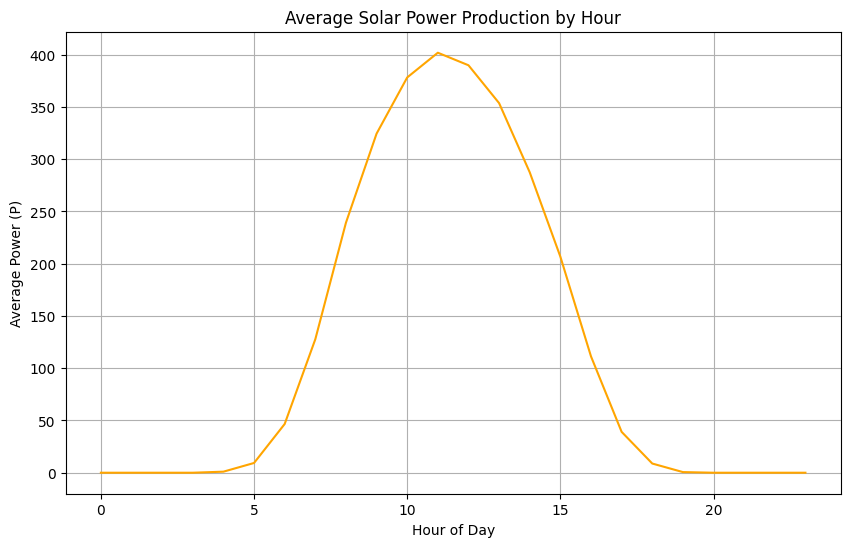

In [27]:
df.groupby(df["Hour"])["power"].mean().plot(figsize=(10,6), color = "orange")
plt.title("Average Solar Power Production by Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Average Power (P)")
plt.grid(True)
plt.show()


**2.4 How much solar power does Aachen produce per month in avarge?**

<Axes: xlabel='month'>

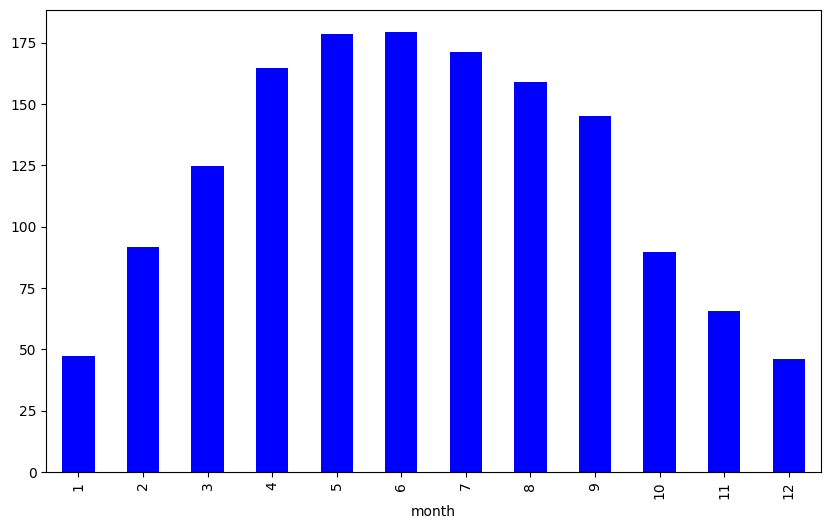

In [28]:
df.groupby("month")["power"].mean().plot( kind = "bar", figsize=(10,6), color= "blue")

**3.4 January vs June average hourly power output**

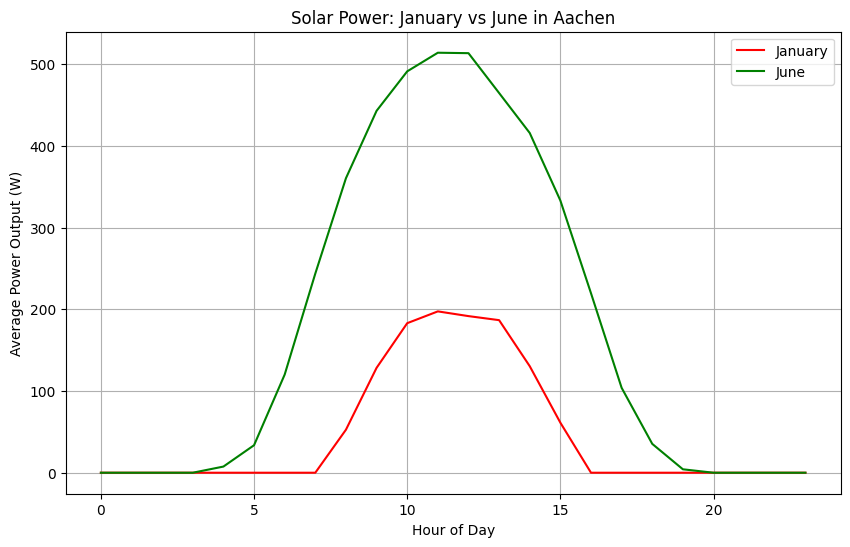

In [29]:
df_Jan = df[df["month"]== 1].groupby("Hour")["power"].mean()
df_June= df[df["month"]==6].groupby("Hour")["power"].mean()   
plt.figure(figsize=(10,6))
plt.plot(df_Jan.index, df_Jan.values, label="January", color ="red")
plt.plot(df_June.index, df_June.values, label="June", color="green")

plt.title("Solar Power: January vs June in Aachen")
plt.xlabel("Hour of Day")
plt.ylabel("Average Power Output (W)")
plt.legend()
plt.grid()

plt.show()

**4.4 How Does Solar Power Production Vary Across Seasons?**

In [41]:
def get_season(month):
    if month in [12, 1, 2]:
        return "Winter"
    elif month in [3, 4, 5]:
        return "Spring"
    elif month in [6, 7, 8]:
        return "Summer"
    else:
        return "Autumn"

df["season"] = df["month"].apply(get_season)

In [44]:
seasonal_power = df.groupby("season")["power"].mean()

seasonal_power


season
Autumn     99.926613
Spring    155.875298
Summer    169.762688
Winter     60.734523
Name: power, dtype: float64

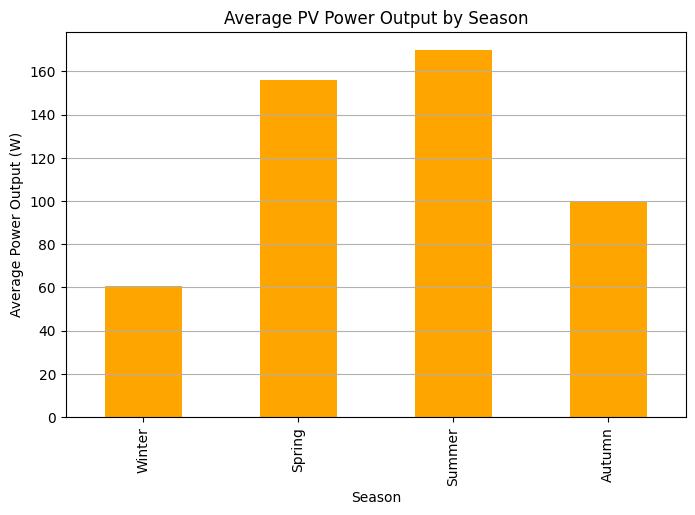

In [45]:
plt.figure(figsize=(8,5))

seasonal_power.loc[
    ["Winter", "Spring", "Summer", "Autumn"]
].plot(kind="bar", color ="orange")

plt.title("Average PV Power Output by Season")
plt.xlabel("Season")
plt.ylabel("Average Power Output (W)")
plt.grid(axis="y")

plt.show()

### 4.5 Correlation Analysis

<Axes: >

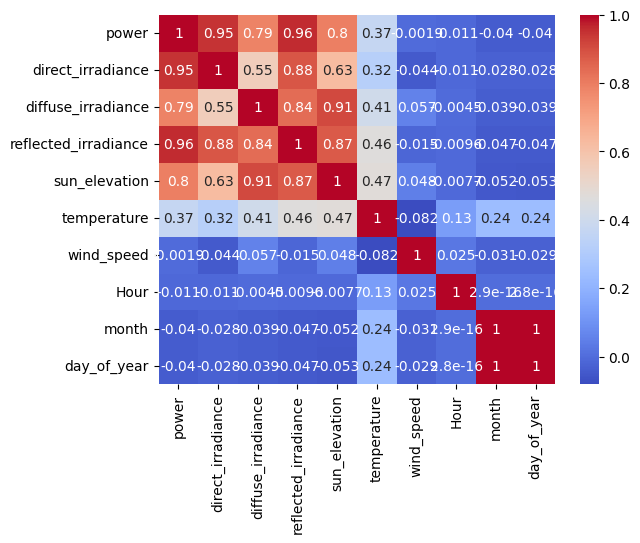

In [46]:
sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap="coolwarm"
)